# A low-level Gaussian Process API

Built on one idea:

> **A GP prior is an `MvNormal`. Everything else is generic linear-Gaussian
> machinery that knows nothing about GPs.**

| Concept | What it actually is |
|---|---|
| GP prior | `pm.MvNormal(mu, K)`, `K = kernel(X)` |
| Integrating the latent out | `pymc_extras.marginalize` |
| Posterior over the latent | `pymc_extras.conditional` |
| GP conditional mean | `project` |
| GP conditional covariance | `conditional_covariance` |
| Prediction | `conditional_at`, then the model's own likelihood |
| Sparse / variational GP | `project` onto inducing inputs, stock ADVI guide |

The only new machinery is a **linear-Gaussian conjugacy rewrite**: for
`f ~ MvNormal(m, K)` and `y ~ Normal(g(f), s)` with `g` affine,

$$y \sim \mathcal{N}(Am + b,\; AKA^\top + S), \qquad
f \mid y \sim \mathcal{N}\big(m + (AK)^\top G^{-1} r,\; K - (AK)^\top G^{-1}(AK)\big)$$

with $G = AKA^\top + S$, $r = y - (Am+b)$. It registers into
`marginal_ir_rewrites_db`; `marginalize` and `conditional` then work unmodified.
It is not GP-specific — it covers regression coefficients and state-space
latents identically.

Because `g` is *any* affine function, "observed at a subset of the inputs" and
"projected from inducing points" are the same operation.

There is **one way to predict**, and it is the same two lines whether the latent
was integrated out, sampled, or fitted variationally. That repetition is the
point of this notebook, so it is left visible rather than factored away.

---

*Generated from `gp_api_build.py`. Edit that, regenerate, then run
`gp_api_execute.py`.*

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt

import pymc_extras as pmx
import pymc_extras.gp as pgp

RNG = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

N_TRAIN = 60
X = np.linspace(0, 1, N_TRAIN)[:, None]
y = np.sin(6 * X.ravel()) + 0.2 * RNG.normal(size=N_TRAIN)
X_pred = np.linspace(-0.3, 1.3, 80)[:, None]

ETA_TRUE, LS_TRUE, SIGMA_TRUE = 1.7, 0.3, 0.2

## Kernels

Callable objects, not matrices: `k(X)` is the covariance, `k(X, Xs)` the
cross-covariance. Keeping the *function* is what lets a model be re-evaluated at
new inputs. They compose with `+` and `*` and scale by scalars, including model
random variables, which is how hyperpriors enter.

k(X)     -> (60, 60)
k(X, Xs) -> (60, 80)  (cross-covariance, rectangular)


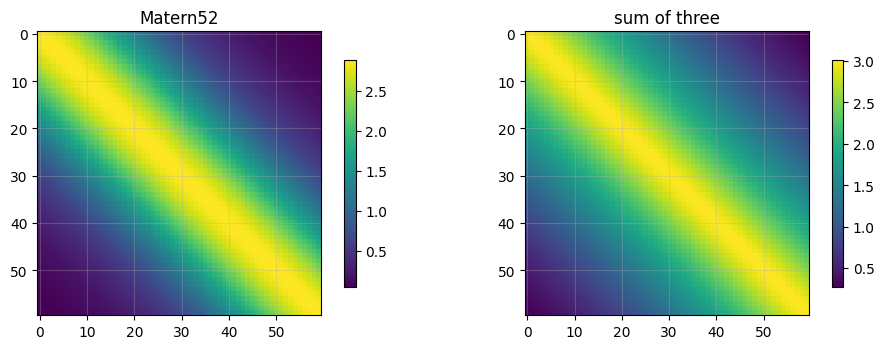

In [2]:
k = ETA_TRUE**2 * pgp.kernels.Matern52(ls=LS_TRUE)
print("k(X)     ->", k(X).eval().shape)
print("k(X, Xs) ->", k(X, X_pred).eval().shape, " (cross-covariance, rectangular)")

k_composite = (
    2.0 * pgp.kernels.ExpQuad(ls=np.array([0.5]))
    + pgp.kernels.Matern32(ls=0.2)
    + pgp.kernels.WhiteNoise(0.1)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, kern, name in zip(axes, [k, k_composite], ["Matern52", "sum of three"]):
    im = ax.imshow(kern(X).eval(), cmap="viridis")
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## The prior

`GP` is a thin constructor, not a new distribution and not an object that owns
inference: it registers a `pm.MvNormal` whose covariance is the kernel evaluated
at `X`. Nothing downstream knows it is a GP.

The model holds the **training inputs only**. Prediction inputs are not needed
here, and putting them in is actively harmful once the latent is sampled:
unobserved rows become coordinates NUTS must explore with no data to constrain
them. The appendix covers defining the prior jointly over several input sets,
and how to drop the rows you are not fitting.

In [3]:
with pm.Model() as latent_model:
    ls = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    eta = pm.Exponential("eta", scale=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    gp = pgp.GP("gp", X, cov=eta**2 * pgp.kernels.Matern52(ls=ls))
    pm.Normal("y", mu=gp, sigma=sigma, observed=y)

print("gp       :", gp.type.shape, " <- training inputs only")
print("it is an :", type(gp.owner.op).__name__)
print("free_RVs :", [v.name for v in latent_model.free_RVs])

gp       : (60,)  <- training inputs only
it is an : MvNormalRV
free_RVs : ['ls', 'eta', 'sigma', 'gp']


## The building blocks

`conditional_at(name, X_new, gp)` is the whole prediction API, and it is the
textbook GP conditional. For a GP over inputs $Z$ and any new inputs $X_*$:

$$A_* = K_{*z}K_{zz}^{-1}, \qquad
\mathbb{E}[f_* \mid f_z] = A_* f_z, \qquad
\operatorname{Cov}[f_* \mid f_z] = K_{**} - A_*K_{z*}$$

It is an `MvNormal` of two public pieces, `project` (the conditional mean
$A_*f_z$) and `conditional_covariance` (the conditional covariance). They are
separate because `project` has a life of its own: it is an *affine* function of
`gp`, so putting a GP on a few inducing inputs and projecting onto the data is
the sparse construction, and needs no approximation-specific machinery. That is
what the variational section below does.

These were written for the sparse case and turned out to be the GP conditional.
"Inducing points" and "prediction points" are not two ideas: both are some other
set of inputs you want the GP at, reached by the same linear map.

In [4]:
Z_demo = np.linspace(0, 1, 10)[:, None]
X_star = np.linspace(-0.1, 1.1, 7)[:, None]

with pm.Model():
    g_demo = pgp.GP("g", Z_demo, cov=k)
    proj = pgp.project(g_demo, X_star)
    C_full = pgp.conditional_covariance(g_demo, X_star)

f_z = RNG.normal(size=10)
Kzz = k(Z_demo).eval() + 1e-6 * np.eye(10)
Ksz = k(X_star, Z_demo).eval()

print(
    "project              == K_*z K_zz^-1 f_z :",
    np.allclose(proj.eval({g_demo: f_z}), Ksz @ np.linalg.solve(Kzz, f_z)),
)
print(
    "conditional_covariance == K_** - A K_z*  :",
    np.allclose(
        C_full.eval() - 1e-6 * np.eye(7),
        k(X_star).eval() - Ksz @ np.linalg.solve(Kzz, Ksz.T),
        atol=1e-8,
    ),
)

project              == K_*z K_zz^-1 f_z : True
conditional_covariance == K_** - A K_z*  : True


The full matrix rather than the diagonal is what makes draws *joint*, i.e.
actual smooth functions.

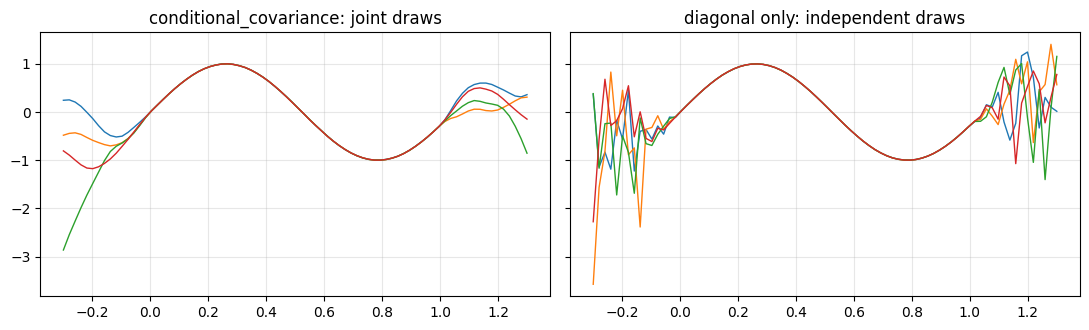

In [5]:
with pm.Model():
    g2 = pgp.GP("g2", X, cov=k)
    mu_j = pgp.project(g2, X_pred)
    C_j = pgp.conditional_covariance(g2, X_pred)
    d_j = pgp.prior_variance_correction(g2, X_pred)
    mu_v = mu_j.eval({g2: np.sin(6 * X.ravel())})
    C_v, d_v = C_j.eval(), d_j.eval()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
axes[0].plot(X_pred.ravel(), RNG.multivariate_normal(mu_v, C_v, size=4).T, lw=1)
axes[0].set_title("conditional_covariance: joint draws")
axes[1].plot(X_pred.ravel(), (mu_v + np.sqrt(d_v) * RNG.normal(size=(4, len(X_pred)))).T, lw=1)
axes[1].set_title("diagonal only: independent draws")
plt.tight_layout()
plt.show()

## A conjugate likelihood: marginalize, then condition

The latent integrates out in closed form, so NUTS samples 3 hyperparameters
instead of 3 + 60.

That leaves nothing to predict *from*: `gp` no longer exists in the model, so
there is no variable for `project` to project. `pmx.conditional` puts it back,
as a free RV whose distribution is the posterior $p(f \mid y)$, still symbolic
in the hyperparameters. It is generic linear-Gaussian machinery, not a GP
function -- the same call recovers any marginalized variable.

That one extra call is the only difference between this path and the two below.
Once `gp` is back, prediction is identical, because `conditional_at` only ever
needed draws of `gp`.

In [6]:
marginal_model = pmx.marginalize(latent_model, ["gp"])
print("free_RVs before:", [v.name for v in latent_model.free_RVs])
print("free_RVs after :", [v.name for v in marginal_model.free_RVs])

with marginal_model:
    idata = pm.sample(draws=400, tune=400, chains=2, random_seed=0, progressbar=False)

print(az.summary(idata, var_names=["ls", "eta", "sigma"], round_to=3))
print("\ntrue: ls =", LS_TRUE, " eta =", ETA_TRUE, " sigma =", SIGMA_TRUE)
print(
    "\nsigma and ls are recovered; eta is weakly identified in a GP marginal"
    "\nlikelihood (it trades off against ls) and the Exponential(1) prior pulls"
    "\nit down. A property of the model, not of the machinery."
)

free_RVs before: ['ls', 'eta', 'sigma', 'gp']
free_RVs after : ['sigma', 'ls', 'eta']


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma, ls, eta]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 110 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
ls     0.332  0.106     0.196     0.517   363.695   337.787  1.002      0.006   
eta    0.908  0.429     0.469     1.697   315.733   379.266  1.005      0.026   
sigma  0.166  0.017     0.143     0.195   455.236   351.628  1.006      0.001   

       mcse_sd  
ls       0.004  
eta      0.032  
sigma    0.001  

true: ls = 0.3  eta = 1.7  sigma = 0.2

sigma and ls are recovered; eta is weakly identified in a GP marginal
likelihood (it trades off against ls) and the Exponential(1) prior pulls
it down. A property of the model, not of the machinery.


free_RVs: ['eta', 'ls', 'sigma', 'gp']  <- gp is back


Sampling: [f_pred, gp, y_new]


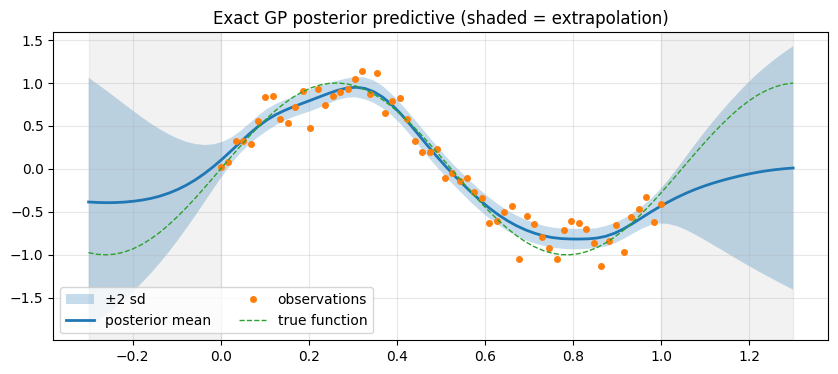

In [7]:
cond_model = pmx.conditional(marginal_model)  # gp comes back as a free RV
print("free_RVs:", [v.name for v in cond_model.free_RVs], " <- gp is back")

# ---- the prediction block, verbatim in every fit path below ----
with cond_model:
    f_pred = pgp.conditional_at("f_pred", X_pred, cond_model["gp"])
    pm.Normal("y_new", mu=f_pred, sigma=cond_model["sigma"])
    pp = pm.sample_posterior_predictive(
        idata, sample_vars=["gp", "f_pred", "y_new"], random_seed=0, progressbar=False
    )
# ----------------------------------------------------------------

f_pred_draws = pp.posterior_predictive["f_pred"].to_numpy().reshape(-1, len(X_pred))
mean_pred, sd_pred = f_pred_draws.mean(0), f_pred_draws.std(0)

xg = X_pred.ravel()
fig, ax = plt.subplots()
ax.fill_between(xg, mean_pred - 2 * sd_pred, mean_pred + 2 * sd_pred, alpha=0.25, label="±2 sd")
ax.plot(xg, mean_pred, lw=2, label="posterior mean")
ax.plot(X.ravel(), y, "o", ms=4, label="observations")
ax.plot(xg, np.sin(6 * xg), ls="--", lw=1, label="true function")
ax.axvspan(-0.3, 0, color="k", alpha=0.05)
ax.axvspan(1.0, 1.3, color="k", alpha=0.05)
ax.set_title("Exact GP posterior predictive (shaded = extrapolation)")
ax.legend(loc="lower left", ncols=2)
plt.show()

## A non-conjugate likelihood: sample the latent, project to predict

With a Bernoulli likelihood the latent no longer integrates out and
`marginalize` declines rather than guessing, so it is sampled instead.

Prediction is **the same block as above**, with `Normal` swapped for the
likelihood this model actually uses. Nothing about it knows whether `gp` arrived
by conditioning or by sampling; it only needs draws of `gp`.

Two things it depends on, both easy to get wrong:

* `f_pred` and `y_new` go on the model **after** fitting. An unobserved RV in
  the fitted model is a *free* RV, so MCMC would sample it — and packing 60
  prediction rows into this problem drops min ESS from 482 to 4.
* Pass **`sample_vars`**, not `var_names`. With `var_names`, a variable already
  in the trace is returned unchanged: no resampling, no warning, just
  `Sampling: []`.

In [8]:
X_b = np.linspace(0, 1, 40)[:, None]
p_true = 1 / (1 + np.exp(-3 * np.sin(6 * X_b.ravel())))
y_b = RNG.binomial(1, p_true)
X_b_pred = np.linspace(-0.2, 1.2, 60)[:, None]
k_b = 3.0**2 * pgp.kernels.Matern52(ls=0.25)

with pm.Model() as bern_model:
    gp_b = pgp.GP("gp", X_b, cov=k_b)  # training inputs only
    pm.Bernoulli("y", logit_p=gp_b, observed=y_b)

try:
    pmx.marginalize(bern_model, ["gp"])
except NotImplementedError as exc:
    print("marginalize declines:", str(exc)[:70], "...")

with bern_model:
    idata_b = pm.sample(draws=500, tune=1000, chains=2, random_seed=0, progressbar=False)
print("max r_hat:", float(np.nanmax(az.rhat(idata_b, var_names=["gp"])["gp"].to_numpy())))

Initializing NUTS using jitter+adapt_diag...


marginalize declines: Cannot marginalize gp with distribution MvNormalRV{name='multivariate_ ...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [gp]


Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 75 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


max r_hat: 1.0068488082379117


Sampling: [f_pred, y_new]


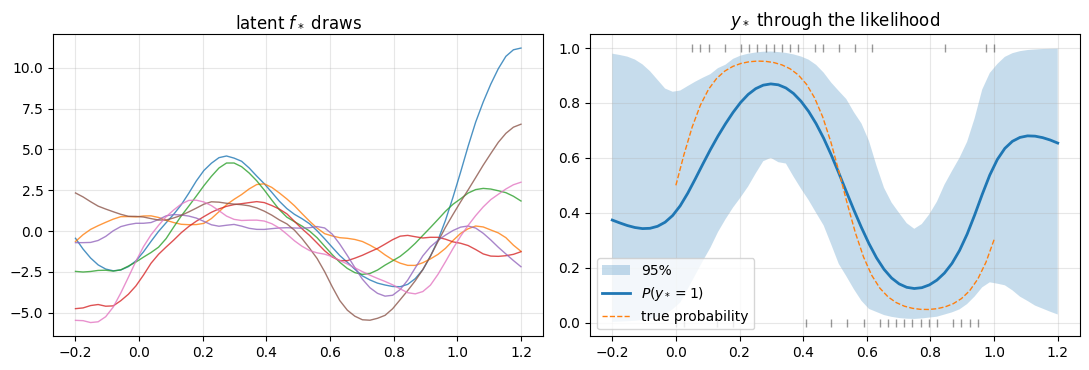

In [9]:
# ---- the prediction block, verbatim from the conjugate section ----
with bern_model:
    f_pred = pgp.conditional_at("f_pred", X_b_pred, gp_b)
    pm.Bernoulli("y_new", logit_p=f_pred)
    pp = pm.sample_posterior_predictive(
        idata_b, sample_vars=["f_pred", "y_new"], random_seed=0, progressbar=False
    )
# -------------------------------------------------------------------

f_draws = pp.posterior_predictive["f_pred"].to_numpy().reshape(-1, len(X_b_pred))
p_draws = 1 / (1 + np.exp(-f_draws))

xb = X_b_pred.ravel()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(xb, f_draws[::150].T, lw=1, alpha=0.8)
axes[0].set_title("latent $f_*$ draws")
axes[1].fill_between(xb, *np.percentile(p_draws, [2.5, 97.5], axis=0), alpha=0.25, label="95%")
axes[1].plot(xb, p_draws.mean(0), lw=2, label="$P(y_*=1)$")
axes[1].plot(X_b.ravel(), p_true, ls="--", lw=1, label="true probability")
axes[1].plot(X_b.ravel(), y_b, "|", ms=6, alpha=0.4, color="k")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("$y_*$ through the likelihood")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

## A non-conjugate likelihood: fit it variationally

Sampling the latent degrades as it grows: 120 training points already gives
`r_hat = 2.5`. Putting the prior on a few inducing inputs and `project`ing onto
the data shrinks the latent to those inducing values, which is also the
construction to reach for with many observations.

No SVGP-specific code exists. The ELBO

$$\mathrm{ELBO} = \mathbb{E}_{q(u)}\big[\log p(y \mid Au)\big] - \mathrm{KL}\big(q(u)\,\|\,p(u)\big)$$

is what `E_q[log p(y,u) - log q(u)]` already computes when `p(u)` is the model
and `q(u)` the guide, so the KL term is never implemented. Prediction is the
same three lines as above, because `Trainer.sample_posterior` returns draws that
`sample_posterior_predictive` consumes directly.

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

latent dim: (15,) | sample_posterior -> DataTree


Sampling: [f_pred, y_new]


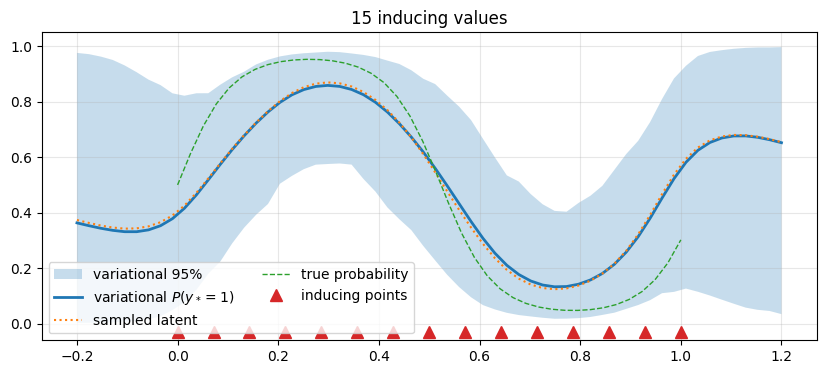

In [10]:
from pymc_extras.inference.advi import AutoMultivariateNormal, Trainer

Z_b = np.linspace(0, 1, 15)[:, None]

with pm.Model() as svgp_model:
    u_b = pgp.GP("u", Z_b, cov=k_b)
    pm.Bernoulli("y", logit_p=pgp.project(u_b, X_b), observed=y_b)

trainer = Trainer(guide=AutoMultivariateNormal, model=svgp_model, n_particles=32, random_seed=0)
trainer.fit(3000)
idata_vi = trainer.sample_posterior(draws=1000, random_seed=0)
print("latent dim:", u_b.type.shape, "| sample_posterior ->", type(idata_vi).__name__)

# ---- the prediction block again, unchanged; only `u_b` differs ----
with svgp_model:
    f_pred = pgp.conditional_at("f_pred", X_b_pred, u_b)
    pm.Bernoulli("y_new", logit_p=f_pred)
    pp_vi = pm.sample_posterior_predictive(
        idata_vi, sample_vars=["f_pred", "y_new"], random_seed=0, progressbar=False
    )
# -------------------------------------------------------------------

p_vi = 1 / (1 + np.exp(-pp_vi.posterior_predictive["f_pred"].to_numpy().reshape(-1, len(X_b_pred))))

fig, ax = plt.subplots()
ax.fill_between(xb, *np.percentile(p_vi, [2.5, 97.5], axis=0), alpha=0.25, label="variational 95%")
ax.plot(xb, p_vi.mean(0), lw=2, label="variational $P(y_*=1)$")
ax.plot(xb, p_draws.mean(0), lw=1.5, ls=":", label="sampled latent")
ax.plot(X_b.ravel(), p_true, ls="--", lw=1, label="true probability")
ax.plot(Z_b.ravel(), np.full(len(Z_b), -0.03), "^", ms=8, label="inducing points")
ax.set_ylim(-0.06, 1.05)
ax.set_title("15 inducing values")
ax.legend(loc="lower left", ncols=2)
plt.show()

## What is missing

1. **Woodbury / structured covariance.** $AKA^\top$ is densified, so the sparse
   construction is correct but scales $O(n^{2.3})$ rather than $O(nm^2)$. The
   main blocker, and the same work item as low-rank ADVI guides.
2. **Non-centered parameterization.** `GP` has no `parameterization=`, which is
   what caps the sampled-latent path at around a hundred observations.

Shallow by construction: kernel coverage, no mean-function namespace, no
multi-output or Kronecker structure, no `predict_f` / `predict_y` wrappers.

### Design notes

* `A` is **never materialized**. The linear map is applied with
  `vectorize_graph`, preserving structure, so a partition stays a slice and
  PyTensor can push it into the kernel graph. `pt.unpack` emits a `Split`, which
  nothing lifts, so `pymc_extras.gp.rewrites` turns a partly-unused `Split` back
  into `Subtensor`s and lets the existing machinery do the rest.
* Affineness is checked by a conservative op whitelist; anything unrecognized
  declines cleanly rather than producing a wrong logp.
* `project` and `conditional_covariance` are the GP conditional, which is why
  all three fits share their prediction code verbatim.

---

## Appendix: packing

Everything above puts the prior on the training inputs and reaches new inputs
with `conditional_at`. The alternative is to define the prior **jointly** over
every input set up front, stacked with `pt.pack`, and let `pt.unpack` slice it:
"observed at the training points" is then `f_train`, a plain slice, which is
affine, which is all the marginalization needs.

It is not the way to predict — it fixes the prediction inputs at build time, and
duplicates what `conditional_at` already does. It is here because it exercises
the one part of the machinery the main path does not: marginalizing *part* of a
variable.

Packing is free when the latent is marginalized (`pymc_extras.gp.rewrites` lifts
the `Split` that `pt.unpack` emits, so an unused partition never enters the
covariance: 4000 prediction rows go from 367 ms to 0.13 ms). It is *not* free
when the latent is sampled. Naming a block and passing that name to
`marginalize` removes it — its factor integrates to one, so no conjugacy is
needed and the posterior over what remains is unchanged.

In [11]:
with pm.Model() as packed_model:
    ls_p = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    Xs, shapes = pt.pack(X, X_pred, keep_axes=-1)
    gp_p = pgp.GP("gp", Xs, cov=pgp.kernels.Matern52(ls=ls_p))
    f_train, f_pred_slice = pt.unpack(gp_p, shapes)
    pgp.name_variable("f_pred", f_pred_slice)  # the handle to marginalize
    pm.Bernoulli("y", logit_p=f_train, observed=(y > 0).astype(int))

reduced = pmx.marginalize(packed_model, ["f_pred"])  # same entry point
print("packed gp :", packed_model["gp"].type.shape)
print("reduced   :", reduced["gp"].type.shape, " <- the 80 unread rows are gone")

# the model you would have written without packing at all
with pm.Model() as unpacked_model:
    ls_u = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    gp_u = pgp.GP("gp", X, cov=pgp.kernels.Matern52(ls=ls_u))
    pm.Bernoulli("y", logit_p=gp_u, observed=(y > 0).astype(int))

point = {"ls_log__": 0.0, "gp": np.zeros(N_TRAIN)}
print(
    "logp matches it exactly:",
    np.isclose(reduced.compile_logp()(point), unpacked_model.compile_logp()(point)),
)

packed gp : (140,)
reduced   : (60,)  <- the 80 unread rows are gone


logp matches it exactly: True


The dropped rows are not discarded: they are kept as an unused output of a
`SubsetMarginalRV`, whose conditional is the Gaussian conditional of the block
given the rest. So `conditional` hands them back under the name you gave them,
with no GP-specific call and no chance of pairing a posterior mean with the
wrong covariance:

In [12]:
cond_sub = pmx.conditional(reduced)
print("free_RVs:", [v.name for v in cond_sub.free_RVs], " <- the dropped block is back")

rv_u = cond_sub["f_pred"]
mu_u, cov_u = rv_u.owner.op.dist_params(rv_u.owner)
f_obs = np.sin(6 * X.ravel())
point = {"ls_log__": np.log(0.3), "gp": f_obs}
got_mu, got_sd = pgp.predictive_fn(cond_sub, [mu_u, pt.sqrt(pt.diag(cov_u))])(point)

# identical to what project / conditional_covariance compute by hand
with unpacked_model:
    ref = pgp.predictive_fn(
        unpacked_model,
        [
            pgp.project(unpacked_model["gp"], X_pred),
            pt.sqrt(pt.diag(pgp.conditional_covariance(unpacked_model["gp"], X_pred))),
        ],
    )
ref_mu, ref_sd = ref(point)
print("vs project / conditional_covariance:  max |mu diff| =", float(np.abs(got_mu - ref_mu).max()))
print("                                      max |sd diff| =", float(np.abs(got_sd - ref_sd).max()))
print("(two equivalent factorizations of an ill-conditioned K; round-off, not disagreement)")

# naming a block the likelihood reads is a conjugacy problem, and declines
with pm.Model() as read_model:
    Xs2, sh2 = pt.pack(X, X_pred, keep_axes=-1)
    g2 = pgp.GP("gp", Xs2, cov=pgp.kernels.Matern52(ls=0.3))
    a, b = pt.unpack(g2, sh2)
    pgp.name_variable("f_train", a)
    pm.Bernoulli("y", logit_p=a, observed=(y > 0).astype(int))
try:
    pmx.marginalize(read_model, ["f_train"])
except NotImplementedError as exc:
    print("declines:", str(exc)[:76], "...")

free_RVs: ['ls', 'gp', 'f_pred']  <- the dropped block is back


vs project / conditional_covariance:  max |mu diff| = 5.0227423808724136e-05
                                      max |sd diff| = 3.5832369091270966e-05
(two equivalent factorizations of an ill-conditioned K; round-off, not disagreement)
declines: 'f_train' is read by the model, so its factor does not integrate to one. Int ...
